Loading CSV …
Pre-processing …


C:\Users\fazil\AppData\Local\Temp\ipykernel_19100\2376684225.py:72: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  h = h.fillna(method='ffill').fillna(method='bfill')
C:\Users\fazil\AppData\Local\Temp\ipykernel_19100\2376684225.py:81: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sh_x = dfz[["left_shoulder_x", "right_shoulder_x"]].mean(1).fillna(method='ffill').fillna(method='bfill')


Building windows …
Dataset shape: 392586 samples, 10 timesteps, 54 features
Training …
Epoch 1/80
4927/4927 [==============================] - 50s 9ms/step - loss: 106501.8281 - mae: 126.2999 - val_loss: 88968.8672 - val_mae: 128.6905
Epoch 2/80
4927/4927 [==============================] - 42s 9ms/step - loss: 106216.2109 - mae: 127.6612 - val_loss: 89030.6172 - val_mae: 125.8429
Epoch 3/80
4927/4927 [==============================] - 42s 9ms/step - loss: 106220.2969 - mae: 127.5541 - val_loss: 88980.4219 - val_mae: 126.8125
Epoch 4/80
4927/4927 [==============================] - 44s 9ms/step - loss: 104388.6172 - mae: 124.3123 - val_loss: 86542.3594 - val_mae: 136.0270
Epoch 5/80
4927/4927 [==============================] - 52s 10ms/step - loss: 98364.3828 - mae: 117.9792 - val_loss: 79767.1328 - val_mae: 109.8603
Epoch 6/80
4927/4927 [==============================] - 54s 11ms/step - loss: 94992.4219 - mae: 113.9217 - val_loss: 79129.2344 - val_mae: 106.6693
Epoch 7/80
4927/4927 [===

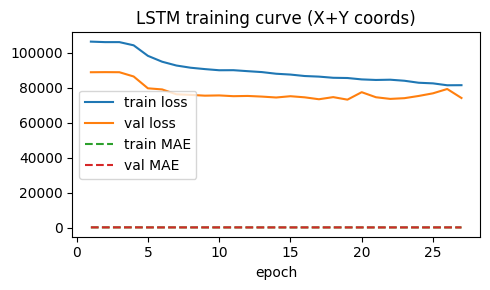

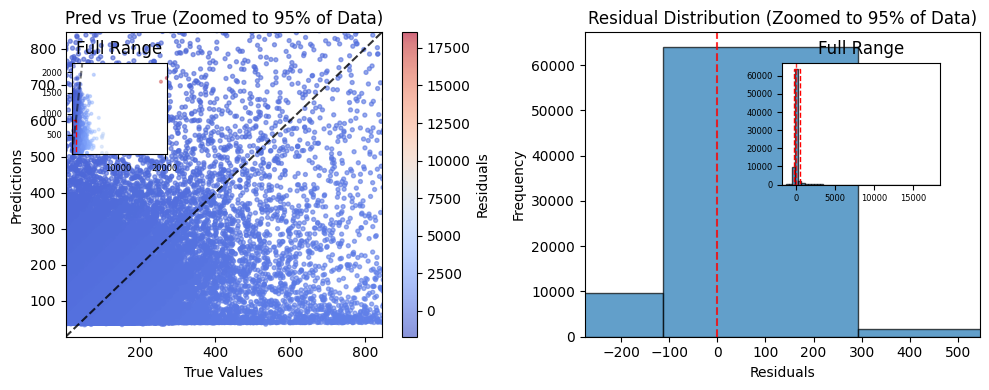

Model + scaler saved to  velocity_forecast_model_lstm_xy_again/


In [ ]:
"""
Velocity-forecast pipeline – LSTM with X and Y coordinates
—————————————————————————————————————————————————————————————————
• Uses X and Y axis key-points (17 joints) from YOLOv8-pose CSVs
• Predicts present vertical velocity only  ← (no future prediction)
• Shows training curves and error plots
• Saves trained model + feature scaler
"""

import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from joblib import dump
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


CSV_FOLDER   = "all together"           
TARGET_COL   = "vertical_velocity (pixel/s)"
Q_PAST       = 10        
BATCH_SIZE   = 64
EPOCHS       = 80
SEED         = 42
SMOOTHING_WINDOW = 3     # for velocity/acceleration calculation

KEYPOINT_NAMES = [
    "nose","left_eye","right_eye","left_ear","right_ear",
    "left_shoulder","right_shoulder","left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip",
    "left_knee","right_knee","left_ankle","right_ankle"
]
X_COLS = [f"{k}_x" for k in KEYPOINT_NAMES]
Y_COLS = [f"{k}_y" for k in KEYPOINT_NAMES]
XY_COLS = X_COLS + Y_COLS

#DATA LOAD + PREP
def load_csvs(folder):
    frames=[]
    for f in glob.glob(os.path.join(folder,"*.csv")):
        d=pd.read_csv(f)
        if not d.empty:
            d["video_id"]=Path(f).stem
            frames.append(d)
    if not frames: raise RuntimeError("No CSVs found")
    return pd.concat(frames,ignore_index=True)

def interpolate_zeros(s, threshold=0.1):
    """
    Interpolate only if the zero value is likely missing data
    (surrounded by non-zero values within threshold distance)
    """
    s = s.reset_index(drop=True).copy()
    for i in s[s == 0].index:
        # Check if zero is likely missing data
        if i > 0 and i < len(s)-1:
            prev_val, next_val = s.iloc[i-1], s.iloc[i+1]
            if prev_val != 0 and next_val != 0 and abs(prev_val - next_val) < threshold:
                s.iloc[i] = (prev_val + next_val) / 2
    return s

def height_norm(df):
    dfz = df.replace(0, np.nan)
    sh = dfz[["left_shoulder_y", "right_shoulder_y"]].mean(1)
    an = dfz[["left_ankle_y", "right_ankle_y"]].mean(1)
    h = (an - sh).abs().replace(0, np.nan)
    
    # Use forward/backward fill for missing heights
    h = h.fillna(method='ffill').fillna(method='bfill')
    # If still missing, use median of all videos
    if h.isna().any():
        h = h.fillna(dfz[Y_COLS].stack().median())
    
    out = df.copy()
    # Normalize Y coordinates
    out[Y_COLS] = (df[Y_COLS].subtract(sh, axis=0)).div(h, axis=0)
    # Normalize X coordinates (centered on shoulders)
    sh_x = dfz[["left_shoulder_x", "right_shoulder_x"]].mean(1).fillna(method='ffill').fillna(method='bfill')
    out[X_COLS] = (df[X_COLS].subtract(sh_x, axis=0)).div(h, axis=0)
    
    return out

def add_delta(df, smoothing_window=3):
    out = df.copy()
    for vid in df.video_id.unique():
        m = df.video_id == vid
        vid_data = df.loc[m].copy()
        
        # Apply simple moving average smoothing
        for col in XY_COLS:
            vid_data[col] = vid_data[col].rolling(
                window=smoothing_window, min_periods=1, center=True
            ).mean()
        
        # Calculate derivatives on smoothed data
        for col in ["nose_y", "left_shoulder_y", "right_shoulder_y", 
                   "left_hip_y", "right_hip_y", "nose_x", 
                   "left_shoulder_x", "right_shoulder_x", 
                   "left_hip_x", "right_hip_x"]:
            v = vid_data[col].diff().fillna(0)
            a = v.diff().fillna(0)
            out.loc[m, f"{col}_velocity"] = v
            out.loc[m, f"{col}_acceleration"] = a
            
            # Set first frame derivatives to 0 (unreliable)
            first_idx = m[m].index[0]
            out.loc[first_idx, f"{col}_velocity"] = 0
            out.loc[first_idx, f"{col}_acceleration"] = 0
            
    return out

def make_windows(df, Q):
    feats = [c for c in df.columns if c not in ("video_id", TARGET_COL)]
    X, yn, video_window_ids = [], [], []
    
    for vid in df.video_id.unique():
        clip = df[df.video_id == vid].reset_index(drop=True)
        
        # Pad short videos with zeros
        if len(clip) < Q:
            padding = pd.DataFrame(0, index=range(Q - len(clip)), columns=clip.columns)
            clip = pd.concat([padding, clip], ignore_index=True)
        
        for t in range(len(clip) - Q + 1):
            X.append(clip.loc[t:t+Q-1, feats].values)
            yn.append(clip.loc[t+Q-1, TARGET_COL])
            video_window_ids.append(vid)
    
    return np.array(X), np.array(yn), feats, np.array(video_window_ids)

def stratified_train_test_split(X, y, video_ids, test_size=0.2, random_state=42):
    """Split ensuring all windows from a video are in same set"""
    unique_videos = np.unique(video_ids)
    train_vids, test_vids = train_test_split(
        unique_videos, test_size=test_size, random_state=random_state
    )
    
    train_mask = np.isin(video_ids, train_vids)
    test_mask = np.isin(video_ids, test_vids)
    
    return X[train_mask], X[test_mask], y[train_mask], y[test_mask]

#LSTM MODEL
def build_lstm(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.LSTM(128, return_sequences=True, dropout=0.2)(inp)
    x = layers.LSTM(64, dropout=0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    v_now = layers.Dense(1, name='v_now')(x)
    m = models.Model(inp, v_now)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

#PLOTS
def plot_history(hist):
    h=hist.history; e=range(1,len(h['loss'])+1)
    plt.figure(figsize=(5,3))
    plt.plot(e,h['loss'],label='train loss')
    plt.plot(e,h['val_loss'],label='val loss')
    plt.plot(e,h['mae'],'--',label='train MAE')
    plt.plot(e,h['val_mae'],'--',label='val MAE')
    plt.xlabel('epoch'); plt.title('LSTM training curve (X+Y coords)'); plt.legend()
    plt.tight_layout(); plt.show()

def plot_scatter_resid(y_true, y_pred):
    import seaborn as sns
    from matplotlib.patches import Rectangle
    
    # Calculate residuals
    resid = y_true - y_pred
    
    # Create figure with subplots
    fig = plt.figure(figsize=(10, 4))
    
    # Scatter plot (Pred vs True)
    ax1 = fig.add_subplot(121)
    sc = ax1.scatter(y_true, y_pred, s=8, alpha=0.6, c=resid, cmap='coolwarm')
    
    # Calculate limits for the main concentration area (95% of data)
    y_true_95 = np.percentile(y_true, [2.5, 97.5])
    y_pred_95 = np.percentile(y_pred, [2.5, 97.5])
    lim_min = min(y_true_95[0], y_pred_95[0])
    lim_max = max(y_true_95[1], y_pred_95[1])
    
    # Set limits for the main plot
    ax1.set_xlim(lim_min, lim_max)
    ax1.set_ylim(lim_min, lim_max)
    
    # Add line of perfect prediction
    ax1.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.8)
    ax1.set_xlabel('True Values')
    ax1.set_ylabel('Predictions')
    ax1.set_title('Pred vs True (Zoomed to 95% of Data)')
    
    # Add colorbar for residuals
    cbar = plt.colorbar(sc, ax=ax1)
    cbar.set_label('Residuals')
    
    # Add inset for full range
    ax1_inset = ax1.inset_axes([0.02, 0.6, 0.3, 0.3])
    ax1_inset.scatter(y_true, y_pred, s=4, alpha=0.4, c=resid, cmap='coolwarm')
    ax1_inset.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', alpha=0.5)
    ax1_inset.set_xlim(y_true.min(), y_true.max())
    ax1_inset.set_ylim(y_pred.min(), y_pred.max())
    ax1_inset.set_title('Full Range')
    ax1_inset.tick_params(axis='both', which='major', labelsize=6)
    
    # Highlight the zoomed area on the inset
    ax1_inset.add_patch(Rectangle(
        (lim_min, lim_min), lim_max-lim_min, lim_max-lim_min,
        fill=False, edgecolor='red', linestyle='--', linewidth=1
    ))
    
    # Residuals histogram
    ax2 = fig.add_subplot(122)
    
    # Calculate histogram with appropriate bins
    resid_range = np.percentile(resid, [1, 99])
    n_bins = min(50, int(len(resid)/10))
    counts, bins, patches = ax2.hist(resid, bins=n_bins, alpha=0.7, edgecolor='black')
    
    # Zoom in on the main concentration of residuals
    resid_95 = np.percentile(resid, [2.5, 97.5])
    ax2.set_xlim(resid_95[0], resid_95[1])
    
    # Add vertical line at zero
    ax2.axvline(x=0, color='red', linestyle='--', alpha=0.8)
    
    ax2.set_xlabel('Residuals')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Residual Distribution (Zoomed to 95% of Data)')
    
    # Add inset for full residual range
    ax2_inset = ax2.inset_axes([0.5, 0.5, 0.4, 0.4])
    ax2_inset.hist(resid, bins=n_bins, alpha=0.7, edgecolor='black')
    ax2_inset.axvline(x=0, color='red', linestyle='--', alpha=0.8, linewidth=1)
    ax2_inset.set_xlim(resid.min(), resid.max())
    ax2_inset.set_title('Full Range')
    ax2_inset.tick_params(axis='both', which='major', labelsize=6)
    
    # Highlight the zoomed area on the inset
    ax2_inset.add_patch(Rectangle(
        (resid_95[0], 0), resid_95[1]-resid_95[0], max(counts),
        fill=False, edgecolor='red', linestyle='--', linewidth=1
    ))
    
    plt.tight_layout()
    plt.show()

#MAIN
def main():
    print("Loading CSV …")
    df_raw=load_csvs(CSV_FOLDER)

    print("Pre-processing …")
    df=df_raw[XY_COLS+['video_id',TARGET_COL]].copy()
    for c in XY_COLS: df[c]=interpolate_zeros(df[c])
    df=add_delta(height_norm(df), smoothing_window=SMOOTHING_WINDOW).dropna()

    print("Building windows …")
    X, yn, feat_cols, video_window_ids = make_windows(df, Q_PAST)
    N, Q, F = X.shape
    print(f"Dataset shape: {N} samples, {Q} timesteps, {F} features")
    
    # Split data by video to prevent data leakage
    X_tr, X_te, yn_tr, yn_te = stratified_train_test_split(
        X, yn, video_window_ids, test_size=0.2, random_state=SEED
    )

    # Fit scaler only on training data to prevent data leakage
    scaler = StandardScaler()
    X_tr_flat = X_tr.reshape(-1, F)
    X_tr_scaled_flat = scaler.fit_transform(X_tr_flat)
    X_tr_scaled = X_tr_scaled_flat.reshape(X_tr.shape)

    # Transform test data using the same scaler
    X_te_flat = X_te.reshape(-1, F)
    X_te_scaled_flat = scaler.transform(X_te_flat)
    X_te_scaled = X_te_scaled_flat.reshape(X_te.shape)

    model = build_lstm((Q,F))
    es = callbacks.EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)

    print("Training …")
    hist=model.fit(X_tr_scaled, yn_tr,
                   validation_data=(X_te_scaled, yn_te), 
                   epochs=EPOCHS, batch_size=BATCH_SIZE,
                   callbacks=[es], verbose=1)

    #evaluation
    v_now_pred = model.predict(X_te_scaled, verbose=0)
    print(f"MAE : {mean_absolute_error(yn_te, v_now_pred.flatten()):.2f}")
    print(f"R²  : {r2_score(yn_te, v_now_pred.flatten()):.3f}")
    print(f"MSE : {mean_squared_error(yn_te, v_now_pred.flatten()):.2f}")
    print(f"MAPE: {mean_absolute_percentage_error(yn_te, v_now_pred.flatten()):.3f}")

    plot_history(hist)
    plot_scatter_resid(yn_te, v_now_pred.flatten())

    # save
    outdir = "velocity_forecast_model_lstm_xy_again"
    os.makedirs(outdir,exist_ok=True)
    model.save(f"{outdir}/vel_lstm_xy_now.h5")
    np.save(f"{outdir}/feature_cols.npy",np.array(feat_cols))
    dump(scaler,f"{outdir}/feature_scaler.pkl")
    print(f"Model + scaler saved to  {outdir}/")

if __name__=="__main__":
    main()

Loading CSV …
Pre-processing …


C:\Users\fazil\AppData\Local\Temp\ipykernel_25032\1418372163.py:72: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  h = h.fillna(method='ffill').fillna(method='bfill')
C:\Users\fazil\AppData\Local\Temp\ipykernel_25032\1418372163.py:81: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sh_x = dfz[["left_shoulder_x", "right_shoulder_x"]].mean(1).fillna(method='ffill').fillna(method='bfill')


Building windows …
Dataset shape: 392586 samples, 10 timesteps, 54 features
Training …
Epoch 1/80
4927/4927 [==============================] - 53s 9ms/step - loss: 106425.0859 - mae: 126.5751 - val_loss: 88995.9141 - val_mae: 126.8420
Epoch 2/80
4927/4927 [==============================] - 50s 10ms/step - loss: 106189.2656 - mae: 127.7572 - val_loss: 89007.7656 - val_mae: 126.3378
Epoch 3/80
4927/4927 [==============================] - 51s 10ms/step - loss: 106216.6719 - mae: 127.6401 - val_loss: 89040.6172 - val_mae: 125.2114
Epoch 4/80
4927/4927 [==============================] - 50s 10ms/step - loss: 106197.9844 - mae: 127.6618 - val_loss: 88971.8281 - val_mae: 128.2236
Epoch 5/80
4927/4927 [==============================] - 50s 10ms/step - loss: 104174.0625 - mae: 124.3480 - val_loss: 83870.2734 - val_mae: 115.7241
Epoch 6/80
4927/4927 [==============================] - 50s 10ms/step - loss: 97001.7734 - mae: 115.7784 - val_loss: 78574.8125 - val_mae: 115.2550
Epoch 7/80
4927/4927 

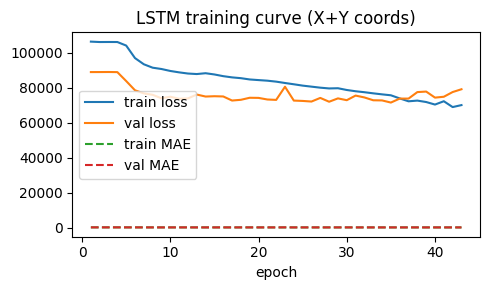

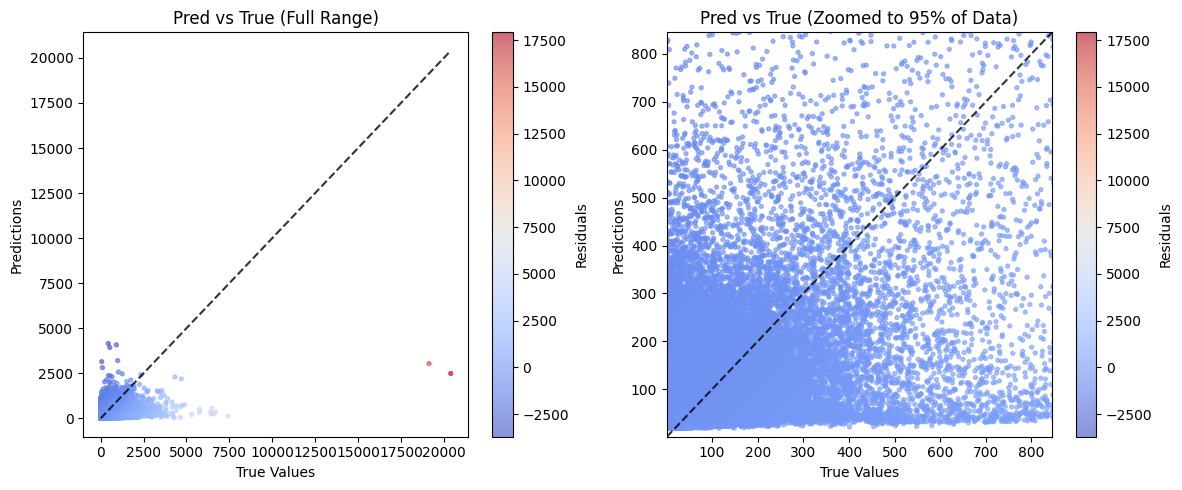

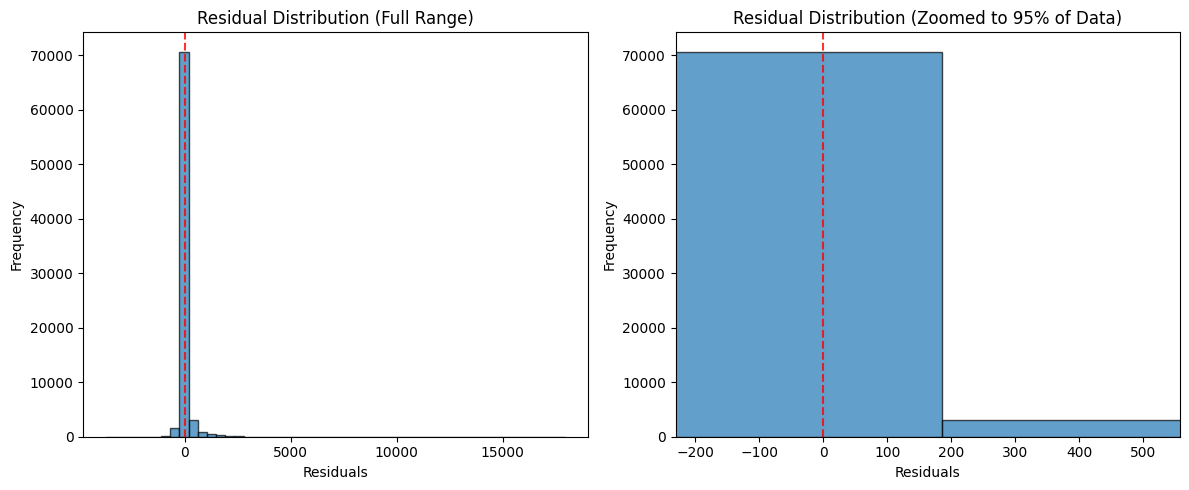

Model + scaler saved to  velocity_forecast_model_lstm_xy_now/


In [1]:
"""
Velocity-forecast pipeline – LSTM with X and Y coordinates
—————————————————————————————————————————————————————————————————
• Uses X and Y axis key-points (17 joints) from YOLOv8-pose CSVs
• Predicts present vertical velocity only  ← (no future prediction)
• Shows training curves and error plots
• Saves trained model + feature scaler
"""

import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from joblib import dump
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ───────── CONFIG ────────────────────────────────────────────────────────────
CSV_FOLDER   = "all together"            # ← change to your folder
TARGET_COL   = "vertical_velocity (pixel/s)"
Q_PAST       = 10        # frames fed in
BATCH_SIZE   = 64
EPOCHS       = 80
SEED         = 42
SMOOTHING_WINDOW = 3     # for velocity/acceleration calculation

KEYPOINT_NAMES = [
    "nose","left_eye","right_eye","left_ear","right_ear",
    "left_shoulder","right_shoulder","left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip",
    "left_knee","right_knee","left_ankle","right_ankle"
]
X_COLS = [f"{k}_x" for k in KEYPOINT_NAMES]
Y_COLS = [f"{k}_y" for k in KEYPOINT_NAMES]
XY_COLS = X_COLS + Y_COLS

# ───────── DATA LOAD + PREP ──────────────────────────────────────────────────
def load_csvs(folder):
    frames=[]
    for f in glob.glob(os.path.join(folder,"*.csv")):
        d=pd.read_csv(f)
        if not d.empty:
            d["video_id"]=Path(f).stem
            frames.append(d)
    if not frames: raise RuntimeError("No CSVs found")
    return pd.concat(frames,ignore_index=True)

def interpolate_zeros(s, threshold=0.1):
    """
    Interpolate only if the zero value is likely missing data
    (surrounded by non-zero values within threshold distance)
    """
    s = s.reset_index(drop=True).copy()
    for i in s[s == 0].index:
        # Check if zero is likely missing data
        if i > 0 and i < len(s)-1:
            prev_val, next_val = s.iloc[i-1], s.iloc[i+1]
            if prev_val != 0 and next_val != 0 and abs(prev_val - next_val) < threshold:
                s.iloc[i] = (prev_val + next_val) / 2
    return s

def height_norm(df):
    dfz = df.replace(0, np.nan)
    sh = dfz[["left_shoulder_y", "right_shoulder_y"]].mean(1)
    an = dfz[["left_ankle_y", "right_ankle_y"]].mean(1)
    h = (an - sh).abs().replace(0, np.nan)
    
    # Use forward/backward fill for missing heights
    h = h.fillna(method='ffill').fillna(method='bfill')
    # If still missing, use median of all videos
    if h.isna().any():
        h = h.fillna(dfz[Y_COLS].stack().median())
    
    out = df.copy()
    # Normalize Y coordinates
    out[Y_COLS] = (df[Y_COLS].subtract(sh, axis=0)).div(h, axis=0)
    # Normalize X coordinates (centered on shoulders)
    sh_x = dfz[["left_shoulder_x", "right_shoulder_x"]].mean(1).fillna(method='ffill').fillna(method='bfill')
    out[X_COLS] = (df[X_COLS].subtract(sh_x, axis=0)).div(h, axis=0)
    
    return out

def add_delta(df, smoothing_window=3):
    out = df.copy()
    for vid in df.video_id.unique():
        m = df.video_id == vid
        vid_data = df.loc[m].copy()
        
        # Apply simple moving average smoothing
        for col in XY_COLS:
            vid_data[col] = vid_data[col].rolling(
                window=smoothing_window, min_periods=1, center=True
            ).mean()
        
        # Calculate derivatives on smoothed data
        for col in ["nose_y", "left_shoulder_y", "right_shoulder_y", 
                   "left_hip_y", "right_hip_y", "nose_x", 
                   "left_shoulder_x", "right_shoulder_x", 
                   "left_hip_x", "right_hip_x"]:
            v = vid_data[col].diff().fillna(0)
            a = v.diff().fillna(0)
            out.loc[m, f"{col}_velocity"] = v
            out.loc[m, f"{col}_acceleration"] = a
            
            # Set first frame derivatives to 0 (unreliable)
            first_idx = m[m].index[0]
            out.loc[first_idx, f"{col}_velocity"] = 0
            out.loc[first_idx, f"{col}_acceleration"] = 0
            
    return out

def make_windows(df, Q):
    feats = [c for c in df.columns if c not in ("video_id", TARGET_COL)]
    X, yn, video_window_ids = [], [], []
    
    for vid in df.video_id.unique():
        clip = df[df.video_id == vid].reset_index(drop=True)
        
        # Pad short videos with zeros
        if len(clip) < Q:
            padding = pd.DataFrame(0, index=range(Q - len(clip)), columns=clip.columns)
            clip = pd.concat([padding, clip], ignore_index=True)
        
        for t in range(len(clip) - Q + 1):
            X.append(clip.loc[t:t+Q-1, feats].values)
            yn.append(clip.loc[t+Q-1, TARGET_COL])
            video_window_ids.append(vid)
    
    return np.array(X), np.array(yn), feats, np.array(video_window_ids)

def stratified_train_test_split(X, y, video_ids, test_size=0.2, random_state=42):
    """Split ensuring all windows from a video are in same set"""
    unique_videos = np.unique(video_ids)
    train_vids, test_vids = train_test_split(
        unique_videos, test_size=test_size, random_state=random_state
    )
    
    train_mask = np.isin(video_ids, train_vids)
    test_mask = np.isin(video_ids, test_vids)
    
    return X[train_mask], X[test_mask], y[train_mask], y[test_mask]

# ───────── LSTM MODEL ────────────────────────────────────────────────────────
def build_lstm(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.LSTM(128, return_sequences=True, dropout=0.2)(inp)
    x = layers.LSTM(64, dropout=0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    v_now = layers.Dense(1, name='v_now')(x)
    m = models.Model(inp, v_now)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

# ───────── PLOTS ─────────────────────────────────────────────────────────────
def plot_history(hist):
    h=hist.history; e=range(1,len(h['loss'])+1)
    plt.figure(figsize=(5,3))
    plt.plot(e,h['loss'],label='train loss')
    plt.plot(e,h['val_loss'],label='val loss')
    plt.plot(e,h['mae'],'--',label='train MAE')
    plt.plot(e,h['val_mae'],'--',label='val MAE')
    plt.xlabel('epoch'); plt.title('LSTM training curve (X+Y coords)'); plt.legend()
    plt.tight_layout(); plt.show()

def plot_scatter_resid(y_true, y_pred):
    import seaborn as sns
    
    # Calculate residuals
    resid = y_true - y_pred
    
    # Create separate figures for original and zoomed views
    # Figure 1: Scatter plots
    fig1, (ax1_orig, ax1_zoom) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Original scatter plot
    sc1 = ax1_orig.scatter(y_true, y_pred, s=8, alpha=0.6, c=resid, cmap='coolwarm')
    ax1_orig.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', alpha=0.8)
    ax1_orig.set_xlabel('True Values')
    ax1_orig.set_ylabel('Predictions')
    ax1_orig.set_title('Pred vs True (Full Range)')
    
    # Add colorbar for residuals
    cbar1 = plt.colorbar(sc1, ax=ax1_orig)
    cbar1.set_label('Residuals')
    
    # Zoomed scatter plot
    # Calculate limits for the main concentration area (95% of data)
    y_true_95 = np.percentile(y_true, [2.5, 97.5])
    y_pred_95 = np.percentile(y_pred, [2.5, 97.5])
    lim_min = min(y_true_95[0], y_pred_95[0])
    lim_max = max(y_true_95[1], y_pred_95[1])
    
    sc2 = ax1_zoom.scatter(y_true, y_pred, s=8, alpha=0.6, c=resid, cmap='coolwarm')
    ax1_zoom.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.8)
    ax1_zoom.set_xlim(lim_min, lim_max)
    ax1_zoom.set_ylim(lim_min, lim_max)
    ax1_zoom.set_xlabel('True Values')
    ax1_zoom.set_ylabel('Predictions')
    ax1_zoom.set_title('Pred vs True (Zoomed to 95% of Data)')
    
    # Add colorbar for residuals
    cbar2 = plt.colorbar(sc2, ax=ax1_zoom)
    cbar2.set_label('Residuals')
    
    plt.tight_layout()
    plt.show()
    
    # Figure 2: Residual plots
    fig2, (ax2_orig, ax2_zoom) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Original residual histogram
    n_bins = min(50, int(len(resid)/10))
    counts_orig, bins_orig, patches_orig = ax2_orig.hist(resid, bins=n_bins, alpha=0.7, edgecolor='black')
    ax2_orig.axvline(x=0, color='red', linestyle='--', alpha=0.8)
    ax2_orig.set_xlabel('Residuals')
    ax2_orig.set_ylabel('Frequency')
    ax2_orig.set_title('Residual Distribution (Full Range)')
    
    # Zoomed residual histogram
    resid_95 = np.percentile(resid, [2.5, 97.5])
    counts_zoom, bins_zoom, patches_zoom = ax2_zoom.hist(resid, bins=n_bins, alpha=0.7, edgecolor='black')
    ax2_zoom.axvline(x=0, color='red', linestyle='--', alpha=0.8)
    ax2_zoom.set_xlim(resid_95[0], resid_95[1])
    ax2_zoom.set_xlabel('Residuals')
    ax2_zoom.set_ylabel('Frequency')
    ax2_zoom.set_title('Residual Distribution (Zoomed to 95% of Data)')
    
    plt.tight_layout()
    plt.show()

# ───────── MAIN ──────────────────────────────────────────────────────────────
def main():
    print("Loading CSV …")
    df_raw=load_csvs(CSV_FOLDER)

    print("Pre-processing …")
    df=df_raw[XY_COLS+['video_id',TARGET_COL]].copy()
    for c in XY_COLS: df[c]=interpolate_zeros(df[c])
    df=add_delta(height_norm(df), smoothing_window=SMOOTHING_WINDOW).dropna()

    print("Building windows …")
    X, yn, feat_cols, video_window_ids = make_windows(df, Q_PAST)
    N, Q, F = X.shape
    print(f"Dataset shape: {N} samples, {Q} timesteps, {F} features")
    
    # Split data by video to prevent data leakage
    X_tr, X_te, yn_tr, yn_te = stratified_train_test_split(
        X, yn, video_window_ids, test_size=0.2, random_state=SEED
    )

    # Fit scaler only on training data to prevent data leakage
    scaler = StandardScaler()
    X_tr_flat = X_tr.reshape(-1, F)
    X_tr_scaled_flat = scaler.fit_transform(X_tr_flat)
    X_tr_scaled = X_tr_scaled_flat.reshape(X_tr.shape)

    # Transform test data using the same scaler
    X_te_flat = X_te.reshape(-1, F)
    X_te_scaled_flat = scaler.transform(X_te_flat)
    X_te_scaled = X_te_scaled_flat.reshape(X_te.shape)

    model = build_lstm((Q,F))
    es = callbacks.EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)

    print("Training …")
    hist=model.fit(X_tr_scaled, yn_tr,
                   validation_data=(X_te_scaled, yn_te), 
                   epochs=EPOCHS, batch_size=BATCH_SIZE,
                   callbacks=[es], verbose=1)

    # ─ evaluation ─
    v_now_pred = model.predict(X_te_scaled, verbose=0)
    print(f"MAE : {mean_absolute_error(yn_te, v_now_pred.flatten()):.2f}")
    print(f"R²  : {r2_score(yn_te, v_now_pred.flatten()):.3f}")
    print(f"MSE : {mean_squared_error(yn_te, v_now_pred.flatten()):.2f}")
    print(f"MAPE: {mean_absolute_percentage_error(yn_te, v_now_pred.flatten()):.3f}")

    plot_history(hist)
    plot_scatter_resid(yn_te, v_now_pred.flatten())

    # ─ save ─
    outdir = "velocity_forecast_model_lstm_xy_now"
    os.makedirs(outdir,exist_ok=True)
    model.save(f"{outdir}/vel_lstm_xy_now.h5")
    np.save(f"{outdir}/feature_cols.npy",np.array(feat_cols))
    dump(scaler,f"{outdir}/feature_scaler.pkl")
    print(f"Model + scaler saved to  {outdir}/")

if __name__=="__main__":
    main()

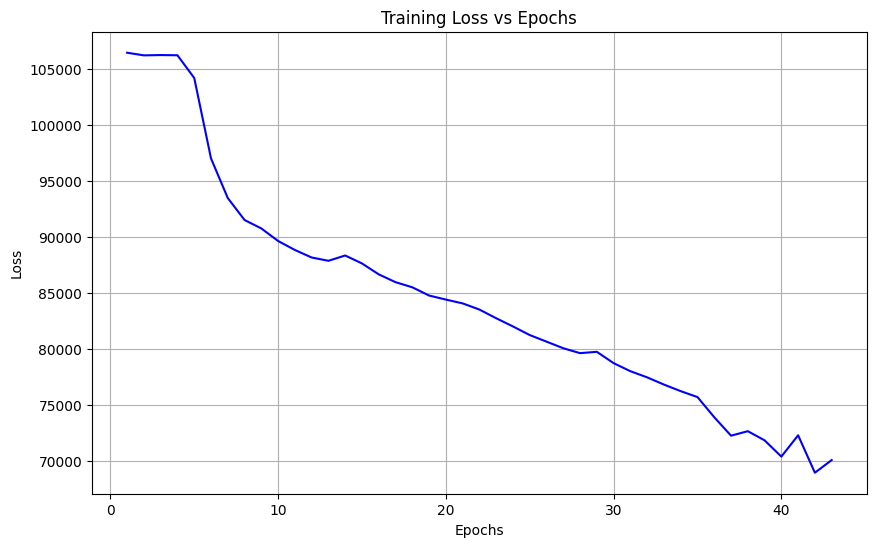

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the training loss data
loss_df = pd.read_csv('training_loss.csv')

# Plot the training loss
plt.figure(figsize=(10,6))
plt.plot(range(1, len(loss_df) + 1), loss_df['loss'], label='Training Loss', color='blue')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


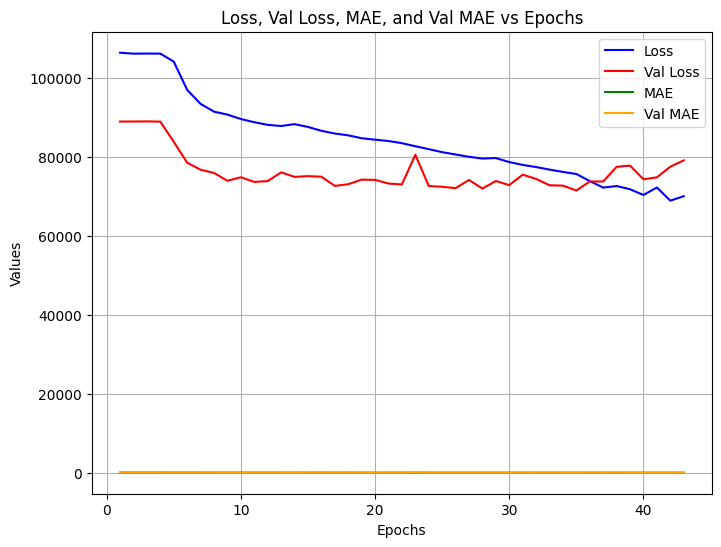

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the CSV file
data_df = pd.read_csv('training_loss.csv')

# Create an array for epochs
epochs = range(1, len(data_df) + 1)

# Plotting the graph
plt.figure(figsize=(8, 6))

# Plot loss and val_loss
plt.plot(epochs, data_df['loss'], label='Loss', color='blue')
plt.plot(epochs, data_df['val_loss'], label='Val Loss', color='red')

# Plot mae and val_mae
plt.plot(epochs, data_df['mae'], label='MAE', color='green')
plt.plot(epochs, data_df['val_mae'], label='Val MAE', color='orange')

# Set title and labels
plt.title('Loss, Val Loss, MAE, and Val MAE vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

# Show plot
plt.show()
